# Etape 7 — Interpretation du modele final
## Projet House Prices — Estimation du prix de vente d'un logement

**Objectif :** comprendre *pourquoi* le modele final (`Ridge`, tune a
l'etape 5, retenu a l'etape 6) predit ce qu'il predit : quelles variables
pesent le plus, dans quel sens, et est-ce coherent avec les intuitions
des etapes 2 et 3 ?

**Comment lire un coefficient ici (2 precisions importantes) :**
1. La cible est `log1p(SalePrice)` : l'effet d'une variable est donc
   **multiplicatif**. Un coefficient `c` correspond a une variation du prix
   d'environ `(exp(c) - 1) x 100` %.
2. **Les unites different selon le type de variable** :
   - variables *numeriques* : standardisees -> effet d'une hausse de
     **1 ecart-type** de la variable ;
   - variables *ordinales* (qualites `Ex/Gd/TA...`) : **non standardisees**
     -> effet d'un **cran de qualite** en plus ;
   - variables *nominales* (one-hot) : effet de **l'appartenance** a la
     categorie (0 ou 1).

   Consequence : on peut comparer les coefficients **au sein d'un meme
   groupe**, mais pas naivement d'un groupe a l'autre. Pour un classement
   equitable de toutes les variables, on utilisera en fin de notebook la
   **permutation importance**, qui ne depend pas de ces unites.

## 1. Chargement du modele et des donnees

In [1]:
import sys
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, make_scorer

sys.path.append('..')
from src.preprocessing import run_pipeline, build_full_pipeline

sns.set_style('whitegrid')
RANDOM_STATE = 42

result = run_pipeline('../data/raw/House_Prices.csv')
X_train_raw, X_test_raw = result['X_train_raw'], result['X_test_raw']
y_train, y_test = result['y_train'], result['y_test']
y_train_log, y_test_log = np.log1p(y_train), np.log1p(y_test)

final_pipeline = joblib.load('../models/Ridge_tuned.joblib')
print(final_pipeline.named_steps['model'])


Ridge(alpha=10, random_state=42)


## 2. Extraction des coefficients

In [2]:
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefs = final_pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df['groupe'] = coef_df['feature'].str.split('__').str[0].map(
    {'num': 'numerique', 'ord': 'ordinale', 'nom': 'nominale'})
coef_df['feature'] = coef_df['feature'].str.split('__', n=1).str[1]
coef_df['effet_pct'] = (np.exp(coef_df['coef']) - 1) * 100

print(coef_df['groupe'].value_counts().to_string())
print(f"\nNombre total de coefficients : {len(coef_df)} (pour {X_train_raw.shape[1]} colonnes brutes, apres encodage)")


groupe
nominale     193
numerique     43
ordinale      16

Nombre total de coefficients : 252 (pour 87 colonnes brutes, apres encodage)


**Interpretation :** les colonnes brutes deviennent 252 colonnes apres
encodage, la grande majorite venant du one-hot des variables nominales
(`Neighborhood` a elle seule en produit 25). Le modele a donc un
coefficient par colonne encodee -- d'ou l'interet, plus bas, de raisonner
aussi au niveau de la variable d'origine.

## 3. Variables numeriques : les plus influentes (comparables entre elles)

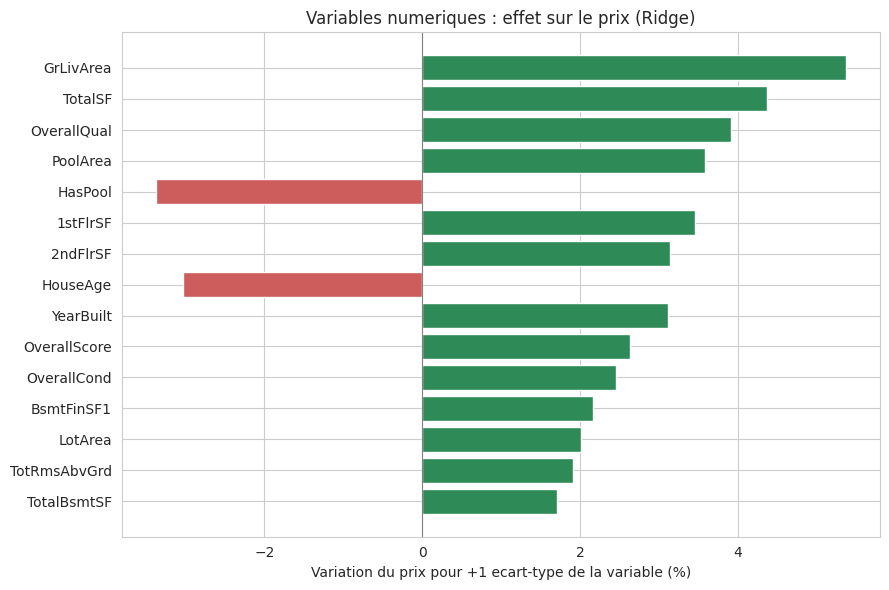

,feature,coef,effet_pct
0,GrLivArea,0.052,5.365
1,TotalSF,0.043,4.371
2,OverallQual,0.038,3.918
3,PoolArea,0.035,3.584
4,HasPool,-0.034,-3.369
5,1stFlrSF,0.034,3.456
6,2ndFlrSF,0.031,3.146
7,HouseAge,-0.031,-3.033
8,YearBuilt,0.031,3.115
9,OverallScore,0.026,2.633


In [3]:
num_df = coef_df[coef_df['groupe'] == 'numerique'].copy()
top_num = num_df.reindex(num_df['coef'].abs().sort_values(ascending=False).index).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['seagreen' if c > 0 else 'indianred' for c in top_num['coef']]
ax.barh(top_num['feature'][::-1], top_num['effet_pct'][::-1], color=colors[::-1])
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Variation du prix pour +1 ecart-type de la variable (%)')
ax.set_title('Variables numeriques : effet sur le prix (Ridge)')
plt.tight_layout()
plt.show()

top_num[['feature', 'coef', 'effet_pct']].round(3).reset_index(drop=True)


**Interpretation :** les surfaces dominent (`GrLivArea`, `TotalSF`,
`1stFlrSF`, `2ndFlrSF`), suivies de `OverallQual` et des variables d'age
(`HouseAge`, `YearBuilt`). Ordre de grandeur : +1 ecart-type de
`GrLivArea` correspond a environ **+5 %** de prix, +1 ecart-type
d'`OverallQual` a environ **+4 %**. Ces effets paraissent faibles
individuellement parce que **Ridge (alpha=10) repartit le poids entre
variables correlees** au lieu de tout attribuer a une seule -- ce qui
amene directement a la section suivante : plusieurs de ces coefficients
ne sont **pas interpretables isolement**.

## 4. Attention a la colinearite : des coefficients qui se partagent ou se compensent

In [4]:
pairs = {
    'Surfaces': ['GrLivArea', 'TotalSF', '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF'],
    'Age': ['HouseAge', 'YearBuilt', 'RemodAge'],
    'Piscine': ['PoolArea', 'HasPool'],
}

for family, cols in pairs.items():
    print(f'=== {family} ===')
    print(coef_df[coef_df['feature'].isin(cols)][['feature', 'coef', 'effet_pct']].round(4).to_string(index=False))
    print('Correlations entre ces variables (train) :')
    print(X_train_raw[cols].corr().round(2).to_string())
    print()


=== Surfaces ===
    feature   coef  effet_pct
TotalBsmtSF 0.0170     1.7135
   1stFlrSF 0.0340     3.4559
   2ndFlrSF 0.0310     3.1457
  GrLivArea 0.0523     5.3652
    TotalSF 0.0428     4.3710
Correlations entre ces variables (train) :
             GrLivArea  TotalSF  1stFlrSF  2ndFlrSF  TotalBsmtSF
GrLivArea         1.00     0.87      0.52      0.70         0.41
TotalSF           0.87     1.00      0.77      0.35         0.81
1stFlrSF          0.52     0.77      1.00     -0.23         0.80
2ndFlrSF          0.70     0.35     -0.23      1.00        -0.19
TotalBsmtSF       0.41     0.81      0.80     -0.19         1.00

=== Age ===
  feature    coef  effet_pct
YearBuilt  0.0307     3.1154
 HouseAge -0.0308    -3.0333
 RemodAge -0.0070    -0.7021
Correlations entre ces variables (train) :


           HouseAge  YearBuilt  RemodAge
HouseAge       1.00      -1.00      0.59
YearBuilt     -1.00       1.00     -0.59
RemodAge       0.59      -0.59      1.00

=== Piscine ===
 feature    coef  effet_pct
PoolArea  0.0352     3.5840
 HasPool -0.0343    -3.3691
Correlations entre ces variables (train) :
          PoolArea  HasPool
PoolArea      1.00     0.99
HasPool       0.99     1.00



**Interpretation :** trois cas typiques de colinearite, chacun avec sa
lecture :
- **Surfaces** : `TotalSF` est, par construction, `TotalBsmtSF + 1stFlrSF
  + 2ndFlrSF`, et `GrLivArea` ~ `1stFlrSF + 2ndFlrSF`. Ces variables sont
  quasi redondantes, donc le poids de "la surface" est **reparti** entre
  elles. On ne peut pas dire "1 ecart-type de `TotalSF` = +4 % *toutes
  choses egales par ailleurs*" : si `TotalSF` augmente, `GrLivArea` et
  `1stFlrSF` augmentent aussi. La bonne lecture est celle de la
  **famille** : la surface, prise dans son ensemble, est le premier
  facteur de prix.
- **Age** : `HouseAge` (= `YrSold - YearBuilt`) et `YearBuilt` sont
  correlees a **-1.00** (quasi la meme information, a l'envers), et leurs
  coefficients sont de **signes opposes** (-3.0 % et +3.1 %). Comme les
  deux variables varient en sens contraire, ces effets **s'additionnent**
  au lieu de s'annuler : un logement plus recent cumule les deux. L'effet
  reel de l'anciennete est donc d'environ **+6 % par ecart-type**, repartis
  sur deux colonnes -- bien plus que ce que suggere chaque coefficient
  pris seul.
- **Piscine** : `PoolArea` (+3.6 %) et `HasPool` (-3.4 %) sont correlees a
  +0.99 avec des coefficients de signes opposes : cette fois, ils
  **s'annulent**. Tres peu de maisons ont une piscine (une seule dans le
  jeu de test), Ridge se contente de repartir du bruit entre deux colonnes
  redondantes. **Ne pas interpreter ces deux coefficients isolement.**

## 5. Variables ordinales et nominales

In [5]:
for groupe in ['ordinale', 'nominale']:
    d = coef_df[coef_df['groupe'] == groupe]
    d = d.reindex(d['coef'].abs().sort_values(ascending=False).index).head(10)
    print(f'=== Top 10 variables {groupe}s (|coef|) ===')
    print(d[['feature', 'coef', 'effet_pct']].round(3).to_string(index=False))
    print()


=== Top 10 variables ordinales (|coef|) ===
     feature   coef  effet_pct
  Functional  0.032      3.253
  GarageQual  0.013      1.348
 KitchenQual  0.013      1.278
   ExterCond -0.012     -1.239
BsmtExposure  0.010      1.046
   ExterQual  0.007      0.691
   HeatingQC  0.007      0.682
      PoolQC  0.006      0.568
BsmtFinType2 -0.005     -0.510
    BsmtQual  0.005      0.503



=== Top 10 variables nominales (|coef|) ===
             feature   coef  effet_pct
    MSZoning_C (all) -0.090     -8.604
Neighborhood_StoneBr  0.076      7.935
Neighborhood_Crawfor  0.076      7.878
 Exterior1st_BrkFace  0.061      6.328
Neighborhood_MeadowV -0.058     -5.641
Neighborhood_BrkSide  0.051      5.240
         MSZoning_FV  0.045      4.614
      MSSubClass_160 -0.043     -4.203
       MSSubClass_70  0.042      4.248
         MSZoning_RL  0.041      4.226



**Interpretation :** les effets ordinaux sont modestes (de l'ordre de
0.5 a 3 % par cran de qualite, `Functional` en tete). Cote nominal, le haut
du classement est domine par des categories **rares** (`MSZoning_C (all)`,
`Exterior1st_BrkFace`...) : un coefficient eleve sur une categorie portee
par tres peu de maisons est peu fiable (peu d'observations pour l'estimer)
-- a lire avec prudence. Les quartiers, plus peuples, sont plus solides :
voir ci-dessous.

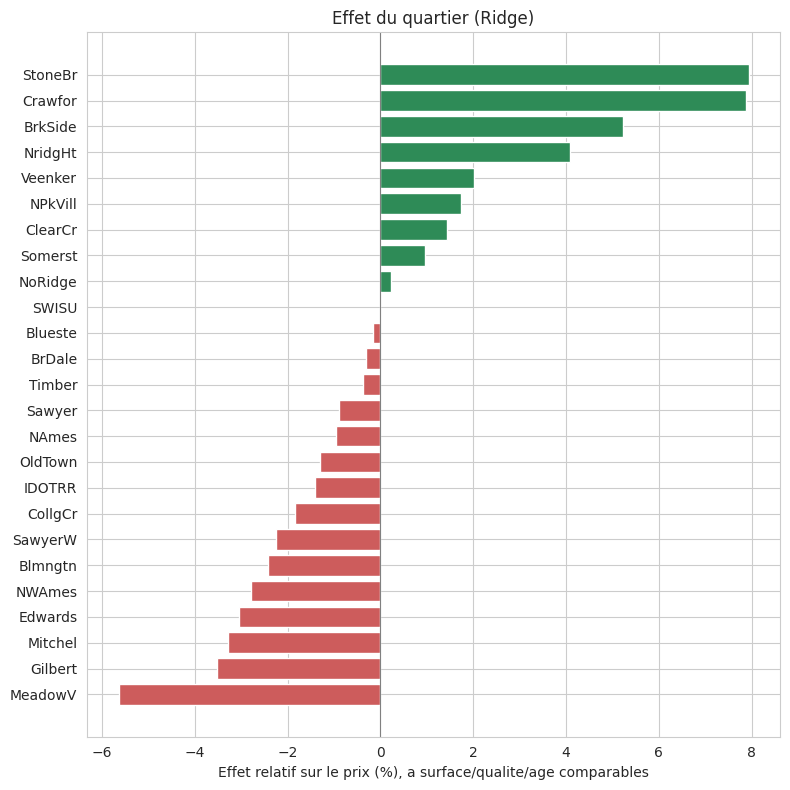

In [6]:
neigh = coef_df[coef_df['feature'].str.startswith('Neighborhood_')].copy()
neigh['quartier'] = neigh['feature'].str.replace('Neighborhood_', '', regex=False)
neigh = neigh.sort_values('effet_pct')

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['seagreen' if c > 0 else 'indianred' for c in neigh['effet_pct']]
ax.barh(neigh['quartier'], neigh['effet_pct'], color=colors)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Effet relatif sur le prix (%), a surface/qualite/age comparables')
ax.set_title('Effet du quartier (Ridge)')
plt.tight_layout()
plt.show()


**Interpretation :** a **surface, qualite et age comparables**, les
meilleurs quartiers (`StoneBr`, `Crawfor`) valent environ **+8 %** et les
moins bien classes (`MeadowV`) environ **-6 %**. C'est bien plus modere
que l'ecart brut entre medianes de quartiers (de 87 000 $ a 318 000 $
dans ce jeu de donnees) : une bonne partie de l'ecart
entre quartiers s'explique en realite par la taille et la qualite des
maisons qui s'y trouvent, pas par l'adresse elle-meme. Ces coefficients
sont **relatifs** (Ridge ne fixe pas de quartier de reference), a lire
comme "mieux/moins bien que la moyenne des autres".

## 6. Verification des signes

In [7]:
expected = {
    'OverallQual': '+', 'GrLivArea': '+', 'TotalSF': '+', 'TotalBath': '+',
    'GarageCars': '+', 'Fireplaces': '+', 'LotArea': '+', 'OverallCond': '+',
    'HouseAge': '-', 'RemodAge': '-',
}

sign_check = coef_df[coef_df['feature'].isin(expected)].copy()
sign_check['signe_attendu'] = sign_check['feature'].map(expected)
sign_check['signe_observe'] = np.where(sign_check['coef'] > 0, '+', '-')
sign_check['coherent'] = sign_check['signe_attendu'] == sign_check['signe_observe']
sign_check[['feature', 'coef', 'signe_attendu', 'signe_observe', 'coherent']].round(4).reset_index(drop=True)


,feature,coef,signe_attendu,signe_observe,coherent
0,LotArea,0.0199,+,+,True
1,OverallQual,0.0384,+,+,True
2,OverallCond,0.0242,+,+,True
3,GrLivArea,0.0523,+,+,True
4,Fireplaces,0.0112,+,+,True
5,GarageCars,0.0154,+,+,True
6,TotalSF,0.0428,+,+,True
7,TotalBath,0.0136,+,+,True
8,HouseAge,-0.0308,-,-,True
9,RemodAge,-0.0070,-,-,True


**Interpretation :** les 10 signes sont conformes a l'intuition metier :
plus de surface, de qualite, de salles de bain, de garage, de cheminees
-> plus cher ; plus ancien / renove depuis longtemps -> moins cher. A noter
`OverallCond` : positif ici, alors que sa correlation *simple* avec le
prix est quasi nulle. Ce n'est pas contradictoire : a qualite de
construction donnee, un logement en meilleur etat vaut plus -- un effet
que la correlation simple masque parce que `OverallCond` est lie a
d'autres variables (les maisons anciennes ont souvent un bon etat mais un
prix plus bas).

## 7. Permutation importance : un classement equitable de toutes les variables

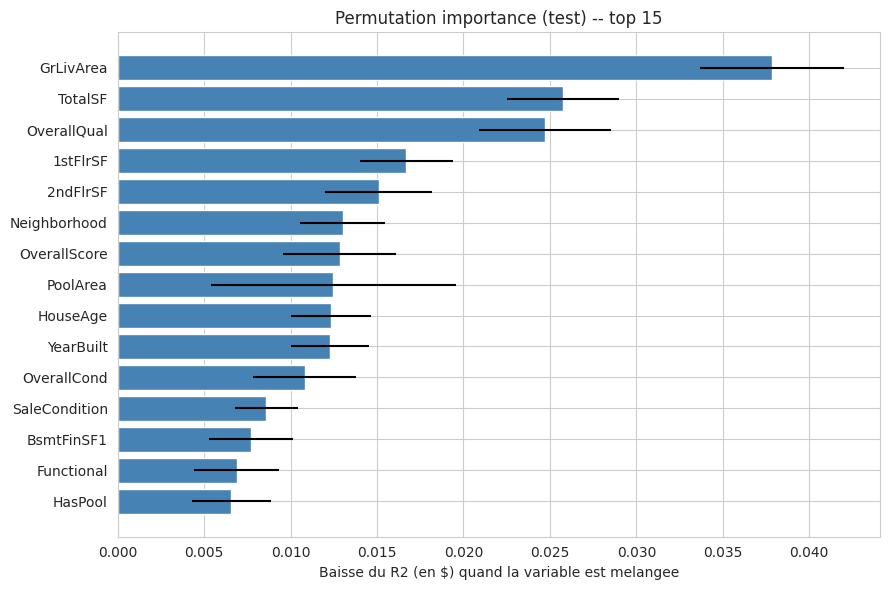

,variable,importance,ecart_type
0,GrLivArea,0.0378,0.0042
1,TotalSF,0.0257,0.0032
2,OverallQual,0.0247,0.0038
3,1stFlrSF,0.0167,0.0027
4,2ndFlrSF,0.0151,0.0031
5,Neighborhood,0.0130,0.0025
6,OverallScore,0.0128,0.0033
7,PoolArea,0.0125,0.0071
8,HouseAge,0.0123,0.0023
9,YearBuilt,0.0123,0.0022


In [8]:
def _r2_dollars(y_true, y_pred):
    return r2_score(np.expm1(y_true), np.expm1(y_pred))

scorer = make_scorer(_r2_dollars)

perm = permutation_importance(
    final_pipeline, X_test_raw, y_test_log,
    scoring=scorer, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
)

perm_df = pd.DataFrame({
    'variable': X_test_raw.columns,
    'importance': perm.importances_mean,
    'ecart_type': perm.importances_std,
}).sort_values('importance', ascending=False).reset_index(drop=True)

top15 = perm_df.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15['variable'][::-1], top15['importance'][::-1],
        xerr=top15['ecart_type'][::-1], color='steelblue')
ax.set_xlabel('Baisse du R2 (en $) quand la variable est melangee')
ax.set_title('Permutation importance (test) -- top 15')
plt.tight_layout()
plt.show()

top15.round(4)


**Principe :** on melange au hasard les valeurs d'**une** variable sur le
jeu de test et on mesure de combien le R² baisse -- plus il baisse, plus le
modele s'appuie sur cette variable. Cela fonctionne au niveau des colonnes
**d'origine** (`Neighborhood` est traitee en bloc, pas dummy par dummy) et
ne depend pas des unites des coefficients.

**Interpretation :** le trio de tete est `GrLivArea`, `TotalSF`,
`OverallQual` -- surface et qualite, comme attendu. `Neighborhood` arrive
en 6e position : un facteur reel, mais moins determinant que la taille et
la qualite. Point de vigilance : `PoolArea` apparait dans le top 10 avec un
**ecart-type eleve** (barre d'erreur large). C'est un artefact des
coefficients qui s'annulent (section 4) : melanger `PoolArea` seule casse
la compensation avec `HasPool`. Le meme raisonnement gonfle
individuellement `HouseAge` et `YearBuilt` (0.012 chacune) : leur
importance reelle ne se voit qu'en les melangeant **ensemble**, ce que fait
la section suivante.

## 7bis. Permutation par famille de variables

In [9]:
families = {
    'Surface': ['GrLivArea', 'TotalSF', '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF'],
    'Qualite globale': ['OverallQual', 'OverallCond', 'OverallScore'],
    'Anciennete': ['HouseAge', 'YearBuilt', 'RemodAge', 'YearRemodAdd'],
    'Quartier': ['Neighborhood'],
    'Piscine': ['PoolArea', 'HasPool'],
}

rng = np.random.default_rng(RANDOM_STATE)
base_r2 = _r2_dollars(y_test_log, final_pipeline.predict(X_test_raw))

rows = []
for name, cols in families.items():
    drops = []
    for _ in range(20):
        X_perm = X_test_raw.copy()
        idx = rng.permutation(len(X_perm))
        X_perm[cols] = X_perm[cols].values[idx]   # memes lignes melangees pour toute la famille
        drops.append(base_r2 - _r2_dollars(y_test_log, final_pipeline.predict(X_perm)))
    rows.append({'famille': name, 'nb_variables': len(cols),
                 'importance': np.mean(drops), 'ecart_type': np.std(drops)})

family_df = pd.DataFrame(rows).sort_values('importance', ascending=False).reset_index(drop=True)
print(f'R2 de reference (test) : {base_r2:.4f}')
family_df.round(4)


R2 de reference (test) : 0.9288


,famille,nb_variables,importance,ecart_type
0,Surface,5,0.2879,0.0196
1,Qualite globale,3,0.0686,0.0080
2,Anciennete,4,0.0662,0.0104
3,Quartier,1,0.0128,0.0031
4,Piscine,2,-0.0000,0.0000


**Principe :** on melange **toute la famille en bloc** (memes lignes
permutees pour toutes ses colonnes), ce qui evite l'artefact des
variables redondantes qui se compensent.

**Interpretation :** classement beaucoup plus net qu'au niveau des
colonnes. La **surface** domine tres largement (la baisse de R² si on la
detruit est de l'ordre de 0.29, contre 0.038 pour la meilleure colonne
prise seule -- le modele peut se rabattre sur les autres surfaces quand
une seule est melangee, pas quand on les melange toutes). La **qualite
globale** (~0.069) et l'**anciennete** (~0.066) suivent, a egalite compte
tenu de l'ecart-type : l'anciennete pese bien plus qu'on ne le croyait en
regardant `HouseAge` ou `YearBuilt` isolement. Le **quartier** (~0.013)
est loin derriere, environ 20 fois moins que la surface. La **piscine**
est a 0 : son importance apparente au niveau des colonnes etait bien un
pur artefact.

## 8. Confrontation avec les etapes 2 et 3 : correlation vs importance

In [10]:
num_cols = X_train_raw.select_dtypes(include=[np.number]).columns
corr = X_train_raw[num_cols].corrwith(y_train).abs().rename('corr_abs').to_frame()
corr['rang_corr'] = corr['corr_abs'].rank(ascending=False).astype(int)

cmp_df = perm_df.set_index('variable').join(corr, how='inner')
cmp_df['rang_importance'] = cmp_df['importance'].rank(ascending=False).astype(int)
cmp_df = cmp_df.sort_values('rang_importance').head(12)
cmp_df[['importance', 'corr_abs', 'rang_importance', 'rang_corr']].round(3)


,importance,corr_abs,rang_importance,rang_corr
variable,,,,
GrLivArea,0.038,0.742,1,3
TotalSF,0.026,0.836,2,1
OverallQual,0.025,0.787,3,2
1stFlrSF,0.017,0.631,4,6
2ndFlrSF,0.015,0.327,5,23
OverallScore,0.013,0.554,6,9
PoolArea,0.012,0.121,7,34
HouseAge,0.012,0.521,8,12
YearBuilt,0.012,0.520,9,13


**Interpretation :** les 3 variables les plus correlees au prix (etapes
2 et 3) -- `TotalSF`, `OverallQual`, `GrLivArea` -- sont aussi les 3 plus
importantes pour le modele : **les intuitions de l'exploration se
confirment**. Difference notable : des variables correlees au prix mais
plus secondaires pour le modele, comme `TotalBath` ou `GarageCars`
(correlation ~0.63). Leur lien avec le prix passe en grande partie par la
taille et la qualite du logement (une grande maison a plus de salles de
bain et de places de garage) : une fois la surface et la qualite connues,
elles n'apportent presque plus rien. **Correlation n'est pas
importance** : la premiere est un lien brut, la seconde est ce qu'une
variable apporte *en plus* des autres. L'inverse existe aussi :
`OverallCond` (correlation 0.08) et `2ndFlrSF` (0.33) sont peu correlees
au prix mais comptent pour le modele, car leur effet n'apparait qu'une
fois les autres variables (qualite, autres surfaces) prises en compte.

## 9. Suite de l'etape 3 : `OverallScore` est-elle utile ?

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_r2(X):
    pipe = build_full_pipeline(Ridge(alpha=10, random_state=RANDOM_STATE), X)
    scores = cross_val_score(pipe, X, y_train_log, cv=kf, scoring=scorer)
    return scores.mean(), scores.std()

m_with, s_with = cv_r2(X_train_raw)
m_without, s_without = cv_r2(X_train_raw.drop(columns=['OverallScore']))

print(f'R2 CV avec OverallScore : {m_with:.4f} (+/- {s_with:.4f})')
print(f'R2 CV sans OverallScore : {m_without:.4f} (+/- {s_without:.4f})')
print(f'Difference              : {m_with - m_without:+.5f}')


R2 CV avec OverallScore : 0.9350 (+/- 0.0100)
R2 CV sans OverallScore : 0.9350 (+/- 0.0102)
Difference              : +0.00003


**Interpretation :** a l'etape 3, on avait releve qu'`OverallScore`
(`OverallQual x OverallCond`) etait *moins* correlee au prix qu'`OverallQual`
seule, avec un retrait possible a la cle. Le test est concluant : **la
retirer ne change pratiquement rien** au R² en validation croisee
(difference de l'ordre de 0.0000, tres inferieure a l'ecart-type de 0.010).
Son coefficient non nul (+2.6 %) n'est que la redistribution du poids
d'`OverallQual` et d'`OverallCond`, dont elle est le produit. Elle est
donc **inutile mais inoffensive** : on la conserve pour ne pas modifier un
pipeline valide, mais elle n'apporte aucune information supplementaire.

## Conclusion de l'etape 7

- **Ce qui fait le prix, selon le modele :** d'abord la **surface**
  (`GrLivArea`, `TotalSF`, ecrasante en importance de famille : ~0.29),
  puis, a egalite, la **qualite globale** (`OverallQual`) et
  l'**anciennete** (~0.07 chacune), et loin derriere le **quartier**
  (~0.013). Au niveau des colonnes, les 3 premieres places de la
  permutation importance (`GrLivArea`, `TotalSF`, `OverallQual`)
  recoupent les 3 variables les plus correlees identifiees aux etapes 2
  et 3.
- **Les signes sont tous coherents** avec l'intuition metier.
- **Limite de lecture a retenir :** les coefficients de variables
  fortement correlees (surfaces, age, piscine) ne s'interpretent pas
  isolement -- le poids est reparti ou compense entre elles. Il faut
  raisonner par **famille** de variables, et s'appuyer sur la permutation
  importance pour un classement fiable.
- **Effet du quartier plus modere qu'il n'y paraissait** a l'etape 2 :
  une fois la taille et la qualite prises en compte, l'ecart entre le
  meilleur et le moins bon quartier est d'environ 14 points de pourcentage
  (+8 % / -6 %), pas de plusieurs dizaines de milliers de dollars.
- **`OverallScore` (etape 3) : sans effet mesurable** -- inoffensive, mais
  inutile.

**Prochaine etape (etape 8) :** application Streamlit. Ce diagnostic guide
directement sa conception : les champs a demander **en priorite** a
l'utilisateur sont la surface, la qualite globale et l'annee de
construction (le quartier vient ensuite) ; les variables a faible importance pourront recevoir une
valeur par defaut sans degrader sensiblement la prediction.